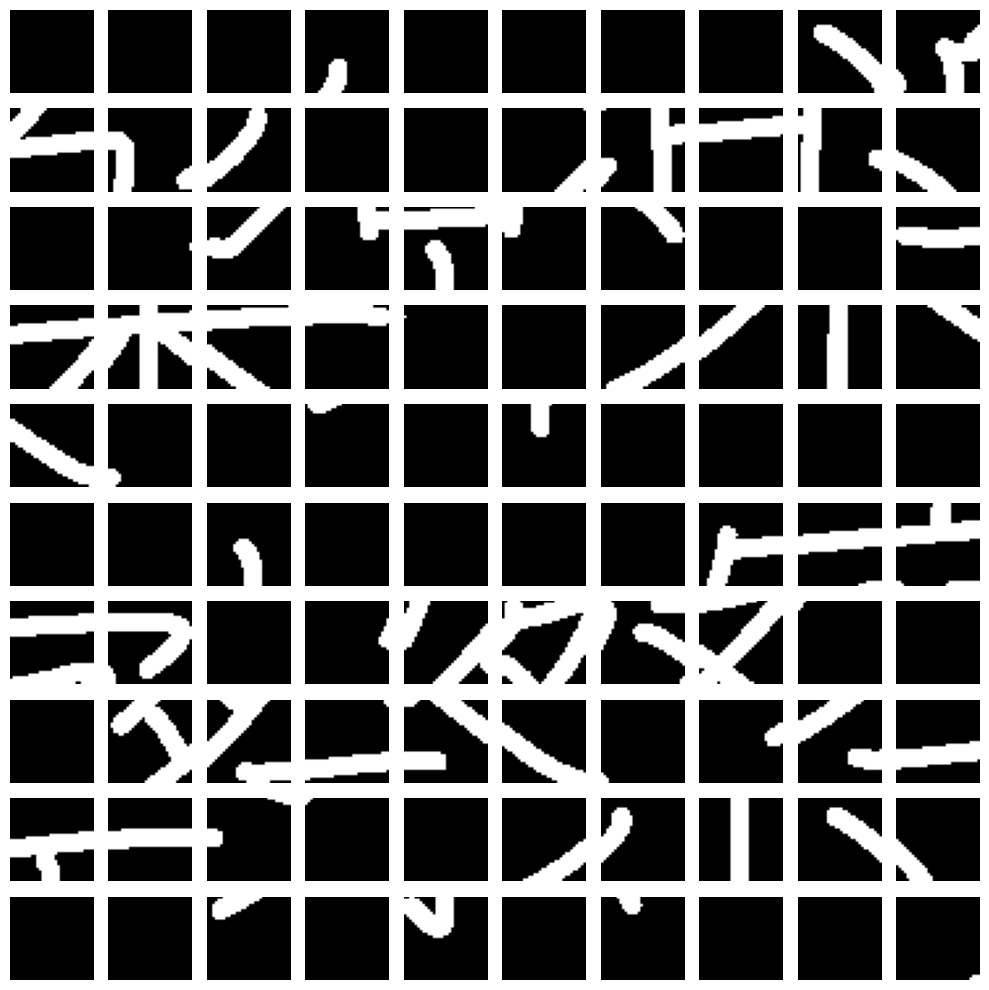

In [13]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

PATCH_SIZE = 32
STRIDE = 32
KANJI_DIR = "/app/data/jouyou"
NUM_PATCHES_TO_SHOW = 100  # 10x10 grid

def extract_patches(img, patch_size=PATCH_SIZE, stride=STRIDE):
    w, h = img.size
    patches = []
    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patch = img.crop((x, y, x + patch_size, y + patch_size))
            patches.append(patch)
    return patches

# Collect random patches across all kanji
all_patches = []
for fname in os.listdir(KANJI_DIR):
    if fname.endswith(".png"):
        img_path = os.path.join(KANJI_DIR, fname)
        img = Image.open(img_path).convert("L")
        patches = extract_patches(img)
        all_patches.extend(patches)

# Select a sample of patches to visualize
selected_patches = all_patches[:NUM_PATCHES_TO_SHOW]

# Show patches in a grid
grid_size = int(np.sqrt(NUM_PATCHES_TO_SHOW))
fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(selected_patches[i], cmap="gray")
    ax.axis('off')

plt.tight_layout()
plt.show()
